# FX Pairs: Model-Based Temporal Features

**Chapter 9: Time Series Analysis**

This notebook fits temporal models inside walk-forward folds and extracts
features for the FX Pairs case study. FX is the primary case study for
Kalman filtering -- the most natural setting for state-space methods
(filtering trend from noise in nearly-efficient prices).

**Learning Objectives**:
- Fit a local linear trend Kalman filter per pair with MLE noise estimation
- Detect USD volatility regimes via HMM on aggregate currency returns
- Extract ARIMA residuals as short-horizon surprise features
- Maintain walk-forward discipline using the canonical train/validation folds

**Book Reference**: Chapter 9, Sections 9.2 (Kalman), 9.5 (HMM), 9.3 (ARIMA)

**Prerequisites**: FX daily price data and the canonical CV configuration from
[`02_labels`](02_labels.ipynb)

**Output Contract**:
- `features/model_based.parquet` -- Temporal features aligned with Ch8
- Keys: `timestamp`, `symbol`, `fold` (fold is metadata, not a feature)
- All features use filtered (not smoothed) estimates
- Each fold contains train+validation features (downstream models select per fold)

In [1]:
"""FX Pairs: Temporal Features."""

import json
import logging
import warnings
from datetime import date

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from hmmlearn.hmm import GaussianHMM
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from ml4t.diagnostic.splitters.calendar import TradingCalendar
from scipy.optimize import minimize
from scipy.stats import spearmanr
from statsmodels.tsa.arima.model import ARIMA

from data import load_fx_pairs
from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")
logging.getLogger("hmmlearn.base").setLevel(logging.ERROR)

In [2]:
CASE_STUDY_ID = "fx_pairs"
PRIMARY_LABEL = "fwd_ret_1d"
# Use 0 for all symbols/folds. Test mode uses 3 symbols and 2 folds.
MAX_SYMBOLS = 0
MAX_FOLDS = 0
# Test mode uses 50 iterations and 3 HMM restarts.
KALMAN_MAXITER = 300
START_DATE = "2011-01-01"
N_HMM_RESTARTS = 10

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"
FEATURES_DIR = CASE_DIR / "features"

ARIMA_ORDER = (1, 0, 1)

## 1. Load Data and CV Config

In [4]:
# Aggregate 4H bars to daily using CME_FX calendar (matches labels pipeline)
fx_4h = load_fx_pairs(
    frequency="4h",
    start_date=START_DATE,
).select(["symbol", "timestamp", "open", "high", "low", "close", "volume"])

cal = TradingCalendar("CME_FX")
sessions = cal.get_sessions(pd.DatetimeIndex(fx_4h["timestamp"].to_pandas()))
# Retain the original 4H timestamp as `bar_ts` so OHLC sort_by inside agg
# is order-safe (polars group_by does not contractually preserve row order).
fx_4h = (
    fx_4h.rename({"timestamp": "bar_ts"})
    .with_columns(pl.Series("timestamp", sessions.values).cast(pl.Date))
    .drop_nulls("timestamp")
)
prices = (
    fx_4h.group_by(["symbol", "timestamp"])
    .agg(
        pl.col("open").sort_by("bar_ts").first().alias("open"),
        pl.col("high").max().alias("high"),
        pl.col("low").min().alias("low"),
        pl.col("close").sort_by("bar_ts").last().alias("close"),
        pl.col("volume").sum().alias("volume"),
    )
    .sort(["symbol", "timestamp"])
)

### Select the Universe

In [5]:
SYMBOLS = sorted(prices["symbol"].unique().to_list())
if MAX_SYMBOLS:
    SYMBOLS = SYMBOLS[:MAX_SYMBOLS]
    prices = prices.filter(pl.col("symbol").is_in(SYMBOLS))
n_symbols = len(SYMBOLS)
dates = prices.filter(pl.col("symbol") == SYMBOLS[0])["timestamp"].sort().to_list()

print(f"Loaded: {n_symbols} pairs, {len(dates)} dates")
print(f"Period: {dates[0]} to {dates[-1]}")

Loaded: 20 pairs, 3874 dates
Period: 2011-01-03 to 2025-12-31


## 2. Resolve the Walk-Forward Folds Before Anything Is Fitted

The boundaries come from `generate_cv_splits` reading the label frame and the
window in `setup.yaml`. This is the same route the downstream loader takes, so
a `fold` id in this artifact selects the same window there as it does here.

An earlier version of this notebook replayed a stored `config/cv_config.json`
instead. A stored splits array cannot track a changed calendar, and this one
had drifted furthest of all: it numbers folds oldest-first while the canonical
route numbers them newest-first, so `fold = 0` named opposite windows on the
two sides of the join.

In [6]:
all_dates = sorted(prices["timestamp"].unique().to_list())

SETUP = load_setup_config(CASE_STUDY_ID)
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"

label_frame = pl.read_parquet(LABELS_DIR / f"{PRIMARY_LABEL}.parquet")
raw_folds = generate_cv_splits(
    label_frame.select("timestamp").unique().sort("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
)
folds = []
for split in raw_folds:
    fold = {
        "fold": int(split["fold"]),
        "train_start": pd.Timestamp(split["train_start"]).date(),
        "train_end": pd.Timestamp(split["train_end"]).date(),
        "val_start": pd.Timestamp(split["val_start"]).date(),
        "val_end": pd.Timestamp(split["val_end"]).date(),
    }
    fold["n_train"] = sum(fold["train_start"] <= d <= fold["train_end"] for d in all_dates)
    fold["n_val"] = sum(fold["val_start"] <= d <= fold["val_end"] for d in all_dates)
    folds.append(fold)

if MAX_FOLDS:
    folds = folds[:MAX_FOLDS]

print(f"Built {len(folds)} walk-forward folds:")
for f in folds:
    print(
        f"  Fold {f['fold']}: train {f['train_start']}..{f['train_end']} "
        f"({f['n_train']} days), validation {f['val_start']}..{f['val_end']} "
        f"({f['n_val']} days)"
    )

Built 8 walk-forward folds:
  Fold 0: train 2018-01-04..2022-12-29 (1289 days), validation 2023-01-03..2023-12-28 (257 days)
  Fold 1: train 2017-01-04..2021-12-30 (1289 days), validation 2022-01-03..2022-12-30 (258 days)
  Fold 2: train 2016-01-05..2020-12-31 (1289 days), validation 2021-01-05..2021-12-31 (258 days)
  Fold 3: train 2015-01-05..2020-01-02 (1289 days), validation 2020-01-06..2021-01-04 (258 days)
  Fold 4: train 2014-01-03..2019-01-02 (1289 days), validation 2019-01-04..2020-01-03 (258 days)
  Fold 5: train 2013-01-03..2018-01-02 (1289 days), validation 2018-01-04..2019-01-03 (258 days)
  Fold 6: train 2012-01-04..2016-12-30 (1289 days), validation 2017-01-04..2018-01-03 (258 days)
  Fold 7: train 2011-01-04..2015-12-31 (1289 days), validation 2016-01-05..2017-01-03 (258 days)


## 3. Kalman Filter (Primary)

The local linear trend model decomposes price into level + slope:

**State**: $\mathbf{x}_t = [\text{level}_t, \text{slope}_t]^\top$

**Transition**: $\mathbf{x}_t = \mathbf{F}\mathbf{x}_{t-1} + \mathbf{w}_t$

**Observation**: $y_t = [1, 0]\mathbf{x}_t + v_t$

Noise parameters $(R, Q)$ are estimated via MLE on each training window.
The filter is then applied forward through the validation period without
re-estimation. We model log prices so level, slope, innovation, and uncertainty
have comparable units across JPY and non-JPY pairs.

In [7]:
def kalman_local_linear(
    prices_arr: np.ndarray,
    observation_noise: float = 1.0,
    level_noise: float = 0.01,
    slope_noise: float = 0.001,
) -> dict[str, np.ndarray]:
    """Local linear trend Kalman filter.

    Returns dict with level, slope, innovation, uncertainty arrays.
    """
    n = len(prices_arr)
    F = np.array([[1.0, 1.0], [0.0, 1.0]])
    H = np.array([[1.0, 0.0]])
    Q = np.array([[level_noise, 0.0], [0.0, slope_noise]])
    R = np.array([[observation_noise]])

    x = np.array([prices_arr[0], 0.0])
    P = np.eye(2) * 10.0

    levels = np.zeros(n)
    slopes = np.zeros(n)
    innovations = np.zeros(n)
    uncertainties = np.zeros(n)
    log_lik = 0.0

    for t in range(n):
        x_pred = F @ x
        P_pred = F @ P @ F.T + Q

        y = prices_arr[t] - H @ x_pred
        S = H @ P_pred @ H.T + R

        log_lik += -0.5 * (np.log(2 * np.pi * S[0, 0]) + y[0] ** 2 / S[0, 0])

        K = P_pred @ H.T @ np.linalg.inv(S)
        x = x_pred + K @ y
        P = (np.eye(2) - K @ H) @ P_pred

        levels[t] = x[0]
        slopes[t] = x[1]
        innovations[t] = y[0]
        uncertainties[t] = P[0, 0]

    return {
        "level": levels,
        "slope": slopes,
        "innovation": innovations,
        "uncertainty": uncertainties,
        "log_likelihood": log_lik,
    }

### Optimize the Kalman Noise Parameters

In [8]:
def neg_log_likelihood(params: np.ndarray, prices_arr: np.ndarray) -> float:
    """Negative log-likelihood for MLE optimization."""
    obs_noise = np.exp(params[0])
    level_noise = np.exp(params[1])
    slope_noise = np.exp(params[2])
    result = kalman_local_linear(prices_arr, obs_noise, level_noise, slope_noise)
    return -result["log_likelihood"]

The optimizer starts from the observed return variance so the noise scales
remain comparable across currency pairs.

In [9]:
def fit_kalman_mle(train_prices: np.ndarray, maxiter: int = 300) -> tuple[float, float, float]:
    """Estimate Kalman noise parameters via MLE on training data."""
    return_variance = max(float(np.var(np.diff(train_prices))), 1e-10)
    x0 = np.log([return_variance * 0.5, return_variance * 0.1, return_variance * 0.01])
    opt = minimize(
        neg_log_likelihood,
        x0,
        args=(train_prices,),
        method="Nelder-Mead",
        options={"maxiter": maxiter},
    )
    return tuple(np.exp(opt.x))

### Run Kalman Filter Walk-Forward

For each fold, we estimate noise parameters on training data, then
apply the filter forward through the full train+validation period.

**Path causality**: Fixed training parameters filter the complete path through
validation. The one-session label buffer updates the state but is not emitted as
a train or validation row. At time $t$, the update uses only observations through
$t$.

In [10]:
def extract_kalman_features(fold: dict, symbol: str) -> list[dict]:
    """Fit one training fold and filter its train-to-validation path."""
    sym_data = prices.filter(pl.col("symbol") == symbol).sort("timestamp")
    sym_dates = sym_data["timestamp"].to_list()
    sym_log_prices = np.log(sym_data["close"].to_numpy())
    train_mask = [fold["train_start"] <= d <= fold["train_end"] for d in sym_dates]
    val_mask = [fold["val_start"] <= d <= fold["val_end"] for d in sym_dates]
    path_mask = [fold["train_start"] <= d <= fold["val_end"] for d in sym_dates]
    train_prices = sym_log_prices[train_mask]
    path_prices = sym_log_prices[path_mask]
    path_dates = [d for d, include in zip(sym_dates, path_mask, strict=True) if include]
    emit_idx = [
        i for i, d in enumerate(path_dates) if d <= fold["train_end"] or d >= fold["val_start"]
    ]
    if len(train_prices) < 252 or sum(val_mask) < 10:
        return []
    opt_params = fit_kalman_mle(train_prices, maxiter=KALMAN_MAXITER)
    filtered = kalman_local_linear(path_prices, *opt_params)
    train_idx = np.array([d <= fold["train_end"] for d in path_dates])
    slope_mean = np.mean(filtered["slope"][train_idx])
    slope_std = np.std(filtered["slope"][train_idx]) + 1e-10
    moving_average = pl.Series(path_prices).rolling_mean(63, min_samples=1).to_numpy()
    return [
        {
            "timestamp": path_dates[i],
            "symbol": symbol,
            "fold": fold["fold"],
            "kalman_trend": filtered["level"][i] - moving_average[i],
            "kalman_slope": filtered["slope"][i],
            "kalman_slope_zscore": (filtered["slope"][i] - slope_mean) / slope_std,
            "kalman_innovation": filtered["innovation"][i],
            "kalman_smoothness": 1.0 / (filtered["uncertainty"][i] + 1e-10),
        }
        for i in emit_idx
    ]

In [11]:
kalman_results = []
for fold in folds:
    for symbol in SYMBOLS:
        try:
            kalman_results.extend(extract_kalman_features(fold, symbol))
        except Exception as exc:
            raise RuntimeError(
                f"Kalman MLE failed for fold {fold['fold']}, symbol {symbol}"
            ) from exc
    if fold["fold"] % 2 == 1 or fold["fold"] == folds[-1]["fold"]:
        n_fold = sum(row["fold"] == fold["fold"] for row in kalman_results)
        print(f"  Kalman fold {fold['fold']}: {n_fold:,} features")

kalman_df = pl.DataFrame(kalman_results)
print(f"\nKalman features: {len(kalman_df):,} rows, {n_symbols} pairs x {len(folds)} folds")

  Kalman fold 1: 30,940 features


  Kalman fold 3: 30,940 features


  Kalman fold 5: 30,940 features


  Kalman fold 7: 30,940 features

Kalman features: 247,500 rows, 20 pairs x 8 folds


## 4. HMM Regimes (Secondary)

We fit a 2-state Gaussian HMM on aggregate USD returns to detect
low- and high-volatility regimes. The HMM is fitted on each training window,
and filtered (not smoothed) probabilities are extracted for the full
train+validation period of each fold. Variance alone does not identify a
risk-off state, so the feature uses the narrower high-volatility label.

In [12]:
# Compute aggregate USD return series (DXY proxy)
USD_LONG = ["USD_CAD", "USD_CHF", "USD_JPY"]
USD_SHORT = ["AUD_USD", "EUR_USD", "GBP_USD", "NZD_USD"]

daily_rets = prices.with_columns(
    (pl.col("close") / pl.col("close").shift(1).over("symbol") - 1).alias("ret")
).drop_nulls(subset=["ret"])

usd_rets = daily_rets.filter(pl.col("symbol").is_in(USD_LONG + USD_SHORT)).with_columns(
    pl.when(pl.col("symbol").is_in(USD_LONG))
    .then(pl.col("ret"))
    .otherwise(-pl.col("ret"))
    .alias("usd_ret")
)

usd_daily = (
    usd_rets.group_by("timestamp")
    .agg(
        pl.col("usd_ret").mean().alias("usd_ret"),
        pl.col("usd_ret").std().alias("usd_vol"),
    )
    .sort("timestamp")
)

# Rolling volatility for HMM input
usd_daily = usd_daily.with_columns(pl.col("usd_ret").rolling_std(21).alias("usd_vol_21d"))

print(f"USD factor series: {len(usd_daily):,} dates")

USD factor series: 3,873 dates


In [13]:
def compute_filtered_probs_manual(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """Compute filtered probabilities P(state_t | obs_{1:t}).

    Uses the forward algorithm. Returns probabilities, not smoothed posteriors.
    """
    framelogprob = model._compute_log_likelihood(X)
    n_samples = X.shape[0]
    n_components = model.n_components

    log_startprob = np.log(model.startprob_ + 1e-300)
    log_transmat = np.log(model.transmat_ + 1e-300)

    fwdlattice = np.zeros((n_samples, n_components))
    fwdlattice[0] = log_startprob + framelogprob[0]

    for t in range(1, n_samples):
        for j in range(n_components):
            fwdlattice[t, j] = framelogprob[t, j] + np.logaddexp.reduce(
                fwdlattice[t - 1] + log_transmat[:, j]
            )

    log_normalizer = np.logaddexp.reduce(fwdlattice, axis=1, keepdims=True)
    filtered = np.exp(fwdlattice - log_normalizer)
    return filtered

Multiple deterministic restarts reduce sensitivity to local likelihood maxima.
Fits whose final likelihood step decreases are excluded rather than silently used.

In [14]:
def fit_best_hmm(X_train: np.ndarray) -> tuple[GaussianHMM, float, int]:
    """Return the best stable training-only HMM fit."""
    best_ll = -np.inf
    best_model = None
    unstable = 0
    for seed in range(N_HMM_RESTARTS):
        try:
            model = GaussianHMM(
                n_components=2,
                covariance_type="full",
                n_iter=100,
                random_state=seed,
                tol=1e-4,
            ).fit(X_train)
            history = list(model.monitor_.history)
            final_delta = history[-1] - history[-2] if len(history) >= 2 else 0.0
            if final_delta < -1e-7:
                unstable += 1
                continue
            score = model.score(X_train)
            if np.isfinite(score) and score > best_ll:
                best_ll, best_model = score, model
        except Exception:
            continue
    if best_model is None:
        raise RuntimeError("No stable HMM fit")
    return best_model, best_ll, unstable

Each fold emits only training and validation dates. The configured buffer updates
the forward state but is not written to either split.

In [15]:
def extract_hmm_features(fold: dict) -> tuple[list[dict], GaussianHMM, np.ndarray, float, int]:
    """Fit one HMM fold and return its filtered feature rows."""
    train_idx = [
        i for i, d in enumerate(valid_dates) if fold["train_start"] <= d <= fold["train_end"]
    ]
    val_idx = [i for i, d in enumerate(valid_dates) if fold["val_start"] <= d <= fold["val_end"]]
    path_idx = [i for i, d in enumerate(valid_dates) if fold["train_start"] <= d <= fold["val_end"]]
    if len(train_idx) < 252 or len(val_idx) < 10:
        raise ValueError(f"Insufficient HMM data for fold {fold['fold']}")
    model, score, unstable = fit_best_hmm(usd_arr[train_idx])
    order = np.argsort([np.trace(covariance) for covariance in model.covars_])
    filtered = compute_filtered_probs_manual(model, usd_arr[path_idx])
    path_dates = [valid_dates[i] for i in path_idx]
    rows = [
        {
            "timestamp": hmm_date,
            "fold": fold["fold"],
            "hmm_regime_prob_high_vol": float(filtered[i, order[1]]),
            "hmm_regime_transition_5d": float(
                filtered[i, order[1]] - filtered[i - 5, order[1]] if i >= 5 else 0.0
            ),
        }
        for i, hmm_date in enumerate(path_dates)
        if hmm_date <= fold["train_end"] or hmm_date >= fold["val_start"]
    ]
    return rows, model, order, score, unstable

The HMM observations are expressed in **percent**, not in native decimal
returns. `GaussianHMM` floors the emission covariance at `min_covar=1e-3`, and
a daily FX log return has a standard deviation near 0.005, so its variance is
about 2.4e-5 - roughly four hundred times smaller than the floor. Fitted in
native units the covariance is set by the regularizer rather than by the data,
and on the shortest fold EM loses positive definiteness outright and no
restart survives the stability check. Scaling by 100 puts the variance above
the floor and every fold converges.

In [16]:
HMM_SCALE = 100.0  # decimal returns -> percent, so min_covar does not dominate

valid_usd = usd_daily.drop_nulls(subset=["usd_ret", "usd_vol_21d"])
valid_dates = valid_usd["timestamp"].to_list()
usd_arr = valid_usd.select(["usd_ret", "usd_vol_21d"]).to_numpy() * HMM_SCALE
hmm_results = []
unstable_hmm_fits = 0
best_model = None
for fold in folds:
    rows, best_model, order, best_ll, unstable = extract_hmm_features(fold)
    hmm_results.extend(rows)
    unstable_hmm_fits += unstable
    print(f"  HMM fold {fold['fold']}: {len(rows)} dates (train+validation), best LL={best_ll:.1f}")
print(f"HMM unstable restarts excluded: {unstable_hmm_fits}")

  HMM fold 0: 1546 dates (train+validation), best LL=843.5


  HMM fold 1: 1547 dates (train+validation), best LL=1145.6


  HMM fold 2: 1547 dates (train+validation), best LL=934.2


  HMM fold 3: 1547 dates (train+validation), best LL=962.5


  HMM fold 4: 1547 dates (train+validation), best LL=837.5


  HMM fold 5: 1547 dates (train+validation), best LL=807.7


  HMM fold 6: 1547 dates (train+validation), best LL=761.1


  HMM fold 7: 1527 dates (train+validation), best LL=567.7
HMM unstable restarts excluded: 15


In [17]:
if hmm_results and best_model is not None:
    trans = best_model.transmat_[np.ix_(order, order)]
    dur_low = 1.0 / (1.0 - trans[0, 0]) if trans[0, 0] < 1 else float("inf")
    dur_high = 1.0 / (1.0 - trans[1, 1]) if trans[1, 1] < 1 else float("inf")
    print("\nHMM Transition Matrix (last fold, sorted by variance):")
    print(f"  {'':>12} {'Low-Vol':>10} {'High-Vol':>10}")
    print(f"  {'Low-Vol':>12} {trans[0, 0]:>10.3f} {trans[0, 1]:>10.3f}")
    print(f"  {'High-Vol':>12} {trans[1, 0]:>10.3f} {trans[1, 1]:>10.3f}")
    print(f"\nExpected regime durations: Low-Vol={dur_low:.0f} days, High-Vol={dur_high:.0f} days")

hmm_df = pl.DataFrame(hmm_results)
print(f"\nHMM features: {len(hmm_df):,} rows")


HMM Transition Matrix (last fold, sorted by variance):
                  Low-Vol   High-Vol
       Low-Vol      0.987      0.013
      High-Vol      0.014      0.986

Expected regime durations: Low-Vol=79 days, High-Vol=74 days

HMM features: 12,355 rows


## 5. ARIMA Residuals (Secondary)

ARIMA(1,0,1) on daily returns per pair. The residual (innovation) captures
short-horizon autocorrelation that the filter removes.

**`fit.apply()` semantics**: After fitting ARIMA on training data, `fit.apply(full_rets)`
re-filters the full series using the *fixed* AR/MA parameters from training --
no re-estimation occurs. This is the correct walk-forward approach: parameters
are locked, only the filter state updates with new observations.

**Why no GARCH?** Garman-Klass rolling volatility (Ch8) and vol ratios already
capture the key volatility dynamics for this universe. GARCH adds marginal value
at the cost of per-pair-per-fold MLE estimation, which is expensive for 20 pairs
x 8 folds. The GK estimator is also more efficient than close-to-close vol
since it uses OHLC data.

In [18]:
def extract_arima_features(fold: dict, symbol: str) -> list[dict]:
    """Fit one training fold and refilter its train-to-validation return path."""
    sym_data = prices.filter(pl.col("symbol") == symbol).sort("timestamp")
    sym_dates = sym_data["timestamp"].to_list()
    sym_close = sym_data["close"].to_numpy()
    sym_rets = np.diff(sym_close) / sym_close[:-1]
    ret_dates = sym_dates[1:]
    train_mask = [fold["train_start"] <= d <= fold["train_end"] for d in ret_dates]
    val_mask = [fold["val_start"] <= d <= fold["val_end"] for d in ret_dates]
    path_mask = [fold["train_start"] <= d <= fold["val_end"] for d in ret_dates]
    train_rets = sym_rets[train_mask]
    path_rets = sym_rets[path_mask]
    path_dates = [d for d, include in zip(ret_dates, path_mask, strict=True) if include]
    if len(train_rets) < 252 or sum(val_mask) < 10:
        return []
    fit = ARIMA(train_rets, order=ARIMA_ORDER).fit()
    train_resid_std = np.std(fit.resid) + 1e-10
    extended = fit.apply(path_rets, refit=False)
    predicted = extended.predict(start=0, end=len(path_rets) - 1)
    return [
        {
            "timestamp": arima_date,
            "symbol": symbol,
            "fold": fold["fold"],
            "arima_forecast": float(predicted[i]),
            "arima_residual": float(path_rets[i] - predicted[i]),
            "arima_residual_zscore": float((path_rets[i] - predicted[i]) / train_resid_std),
        }
        for i, arima_date in enumerate(path_dates)
        if arima_date <= fold["train_end"] or arima_date >= fold["val_start"]
    ]

In [19]:
arima_results = []
for fold in folds:
    for symbol in SYMBOLS:
        try:
            arima_results.extend(extract_arima_features(fold, symbol))
        except Exception as exc:
            raise RuntimeError(
                f"ARIMA fit failed for fold {fold['fold']}, symbol {symbol}"
            ) from exc
    if fold["fold"] % 2 == 0 or fold["fold"] == folds[-1]["fold"]:
        n_fold = sum(row["fold"] == fold["fold"] for row in arima_results)
        print(f"  ARIMA fold {fold['fold']}: {n_fold:,} features")

arima_df = pl.DataFrame(arima_results)
print(f"\nARIMA features: {len(arima_df):,} rows")

  ARIMA fold 0: 30,920 features


  ARIMA fold 2: 30,940 features


  ARIMA fold 4: 30,940 features


  ARIMA fold 6: 30,940 features


  ARIMA fold 7: 30,940 features

ARIMA features: 247,500 rows


## 6. Merge Temporal Features

Combine Kalman, HMM, and ARIMA features into a single DataFrame.
The `fold` column is preserved as metadata -- downstream models use it
to select the correct train+validation features for each walk-forward fold.

In [20]:
# Start with Kalman (per symbol, per date, per fold)
temporal_df = kalman_df.sort(["symbol", "timestamp", "fold"])

# Add HMM features (broadcast across symbols -- market-level, per fold)
if len(hmm_df) > 0:
    temporal_df = temporal_df.join(hmm_df, on=["timestamp", "fold"], how="left", validate="m:1")

# Add ARIMA features (per symbol, per date, per fold)
if len(arima_df) > 0:
    temporal_df = temporal_df.join(
        arima_df, on=["symbol", "timestamp", "fold"], how="left", validate="1:1"
    )

temporal_df = temporal_df.sort(["symbol", "timestamp", "fold"])

# List temporal feature columns (fold is metadata, not a feature)
temporal_feature_cols = [c for c in temporal_df.columns if c not in {"timestamp", "symbol", "fold"}]
duplicate_keys = temporal_df.select(
    pl.struct("timestamp", "symbol", "fold").is_duplicated().sum()
).item()
assert duplicate_keys == 0, f"Duplicate temporal keys: {duplicate_keys}"

print(
    f"\nMerged temporal features: {len(temporal_df):,} rows, {len(temporal_feature_cols)} features"
)
print(f"Features: {temporal_feature_cols}")


Merged temporal features: 247,500 rows, 10 features
Features: ['kalman_trend', 'kalman_slope', 'kalman_slope_zscore', 'kalman_innovation', 'kalman_smoothness', 'hmm_regime_prob_high_vol', 'hmm_regime_transition_5d', 'arima_forecast', 'arima_residual', 'arima_residual_zscore']


## 7. Save Temporal Features

In [21]:
output_path = FEATURES_DIR / "model_based.parquet"

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
temporal_df.write_parquet(output_path)
print(f"Saved: {output_path.relative_to(CASE_DIR)}")
print(f"  Shape: {temporal_df.shape}")

Saved: features/model_based.parquet
  Shape: (247500, 13)


## 8. Incremental Evaluation

Do temporal features add predictive value beyond base features?
We evaluate only each fold's validation rows. Training-row features are valid
inputs for downstream fitting, but they are not out-of-sample evidence. Daily
cross-sectional IC uses sorted Newey-West inference and BH-FDR across all
testable temporal features.

In [22]:
def compute_daily_ic(frame: pl.DataFrame, feature: str, label: str) -> pl.DataFrame:
    """Return a chronologically sorted daily cross-sectional IC series."""
    rows = []
    groups = frame.sort(["timestamp", "symbol"]).partition_by("timestamp", maintain_order=True)
    for group in groups:
        valid = group.select(feature, label).drop_nulls()
        if len(valid) < 8:
            continue
        ic, _ = spearmanr(valid[feature].to_numpy(), valid[label].to_numpy())
        if np.isfinite(ic):
            rows.append((group["timestamp"][0], float(ic)))
    return pl.DataFrame(rows, schema=["timestamp", "ic"], orient="row").sort("timestamp")

In [23]:
validation_frames = [
    temporal_df.filter(
        (pl.col("fold") == fold["fold"])
        & pl.col("timestamp").is_between(fold["val_start"], fold["val_end"], closed="both")
    )
    for fold in folds
]
eval_features = pl.concat(validation_frames).sort(["timestamp", "symbol"])
eval_duplicates = eval_features.select(
    pl.struct("timestamp", "symbol").is_duplicated().sum()
).item()
assert eval_duplicates == 0, f"Overlapping validation features: {eval_duplicates}"

label_col = [c for c in label_frame.columns if c not in {"timestamp", "symbol"}][0]
label_endpoints = label_frame.sort(["symbol", "timestamp"]).with_columns(
    pl.col("timestamp").shift(-1).over("symbol").alias("_label_end")
)
eval_df = eval_features.join(label_endpoints, on=["timestamp", "symbol"], how="inner")
HOLDOUT_START = pd.Timestamp(load_evaluation_config(CASE_STUDY_ID)["holdout_start"]).date()
assert eval_df["_label_end"].max() < HOLDOUT_START, (
    "A validation decision resolves its label inside the holdout window"
)
print(
    f"Out-of-sample eval set: {len(eval_df):,} rows, "
    f"{eval_df['timestamp'].n_unique():,} dates, label: {label_col}"
)

Out-of-sample eval set: 41,260 rows, 2,063 dates, label: fwd_ret_1d


In [24]:
temporal_ic = {}
for feature in temporal_feature_cols:
    ic_series = compute_daily_ic(eval_df, feature, label_col)
    if len(ic_series) >= 20:
        temporal_ic[feature] = compute_ic_hac_stats(ic_series, ic_col="ic", label_horizon=1)

BH-FDR controls the family of simultaneous feature tests. Reduced-symbol test
runs skip this diagnostic because daily cross-sectional IC requires eight pairs.

In [25]:
feature_names = list(temporal_ic)
if feature_names:
    p_values = [temporal_ic[feature]["p_value"] for feature in feature_names]
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)
    eval_summary = pl.DataFrame(
        {
            "feature": feature_names,
            "ic_mean": [temporal_ic[f]["mean_ic"] for f in feature_names],
            "naive_tstat": [temporal_ic[f]["naive_t_stat"] for f in feature_names],
            "hac_tstat": [temporal_ic[f]["t_stat"] for f in feature_names],
            "p_value": p_values,
            "adjusted_p": list(fdr_result["adjusted_p_values"]),
            "significant_fdr05": list(fdr_result["rejected"]),
        }
    ).sort(pl.col("ic_mean").abs(), descending=True)
    n_naive_sig = sum(abs(temporal_ic[f]["naive_t_stat"]) > 1.96 for f in feature_names)
    n_hac_sig = sum(p < 0.05 for p in p_values)
    n_fdr_sig = int(fdr_result["n_rejected"])
    print(f"Features tested: {len(feature_names)} / {len(temporal_feature_cols)}")
    print(f"Naive |t| > 1.96: {n_naive_sig}")
    print(f"HAC p < 0.05: {n_hac_sig}")
    print(f"BH-FDR q < 0.05: {n_fdr_sig}")
    print(eval_summary)
else:
    eval_summary = pl.DataFrame(
        schema={
            "feature": pl.String,
            "ic_mean": pl.Float64,
            "naive_tstat": pl.Float64,
            "hac_tstat": pl.Float64,
            "p_value": pl.Float64,
            "adjusted_p": pl.Float64,
            "significant_fdr05": pl.Boolean,
        }
    )
    n_fdr_sig = 0
    print("Validation IC omitted: the reduced run has fewer than 8 pairs per date.")

Features tested: 8 / 10
Naive |t| > 1.96: 0
HAC p < 0.05: 0
BH-FDR q < 0.05: 0
shape: (8, 7)
┌──────────────────┬───────────┬─────────────┬───────────┬──────────┬────────────┬─────────────────┐
│ feature          ┆ ic_mean   ┆ naive_tstat ┆ hac_tstat ┆ p_value  ┆ adjusted_p ┆ significant_fdr │
│ ---              ┆ ---       ┆ ---         ┆ ---       ┆ ---      ┆ ---        ┆ 05              │
│ str              ┆ f64       ┆ f64         ┆ f64       ┆ f64      ┆ f64        ┆ ---             │
│                  ┆           ┆             ┆           ┆          ┆            ┆ bool            │
╞══════════════════╪═══════════╪═════════════╪═══════════╪══════════╪════════════╪═════════════════╡
│ kalman_trend     ┆ -0.01293  ┆ -1.268036   ┆ -1.285463 ┆ 0.198775 ┆ 0.627501   ┆ false           │
│ kalman_slope_zsc ┆ 0.010189  ┆ 1.160986    ┆ 1.18713   ┆ 0.235313 ┆ 0.627501   ┆ false           │
│ ore              ┆           ┆             ┆           ┆          ┆            ┆                 

### Validation IC Provides No Standalone Selection Rule

Market-level HMM features are constant across pairs and therefore untestable
with cross-sectional IC. The chart applies FDR across the remaining features;
neutral bars are exploratory estimates rather than discoveries.

In [26]:
if len(eval_summary):
    plot_summary = eval_summary.sort("ic_mean")
    leader = eval_summary["feature"][0]
    bar_colors = [
        COLORS["positive"]
        if row["significant_fdr05"] and row["ic_mean"] > 0
        else COLORS["negative"]
        if row["significant_fdr05"]
        else COLORS["amber"]
        if row["feature"] == leader
        else COLORS["neutral"]
        for row in plot_summary.to_dicts()
    ]
    ic_title = (
        "Some model-based features survive FDR on out-of-sample folds"
        if n_fdr_sig
        else "No model-based feature survives FDR on out-of-sample folds"
    )

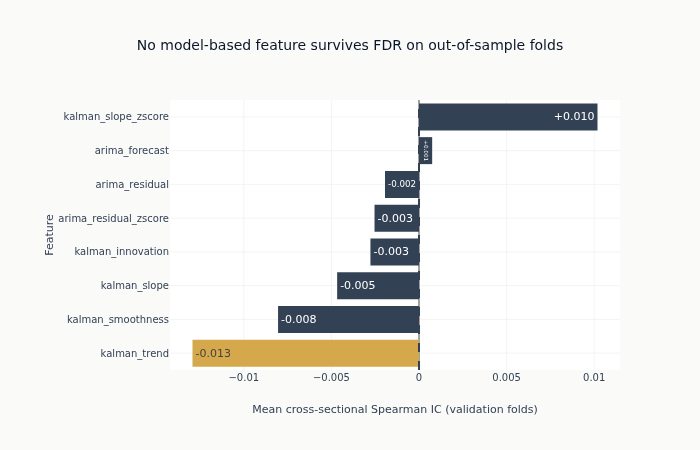

In [27]:
if len(eval_summary):
    fig = go.Figure(
        go.Bar(
            x=plot_summary["ic_mean"],
            y=plot_summary["feature"],
            orientation="h",
            marker_color=bar_colors,
            text=[f"{value:+.3f}" for value in plot_summary["ic_mean"]],
            textposition="inside",
            insidetextanchor="end",
            showlegend=False,
        )
    )
    fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])
    fig.update_layout(
        title=ic_title,
        xaxis_title="Mean cross-sectional Spearman IC (validation folds)",
        yaxis_title="Feature",
        margin={"l": 170},
        height=450,
    )
    fig.show()
else:
    print("Validation IC chart omitted: the reduced-symbol test run has too few pairs per date.")

## 9. High-Volatility Regime Diagnostic

The HMM output is a market-level conditioning variable, not a cross-sectional
signal. This validation-only view shows the filtered probability assigned to
the higher-variance state without interpreting that state as risk-off.

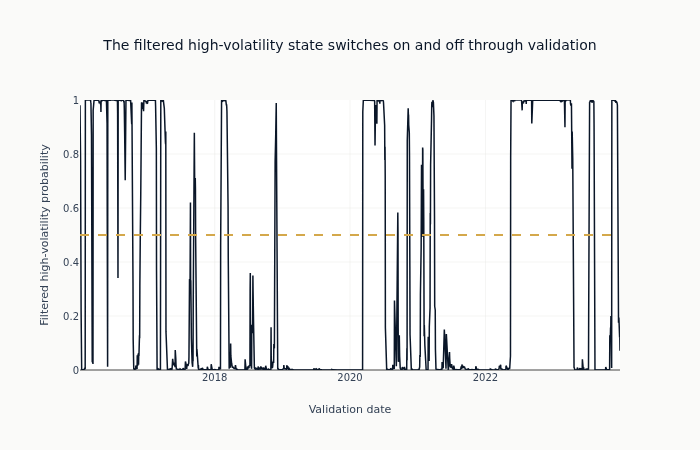

In [28]:
if "hmm_regime_prob_high_vol" in eval_features.columns:
    hmm_validation = (
        eval_features.select("timestamp", "hmm_regime_prob_high_vol")
        .unique("timestamp", keep="last")
        .sort("timestamp")
        .drop_nulls()
    )
    high_vol_share = float((hmm_validation["hmm_regime_prob_high_vol"] >= 0.5).mean())
    fig = go.Figure(
        go.Scatter(
            x=hmm_validation["timestamp"],
            y=hmm_validation["hmm_regime_prob_high_vol"],
            mode="lines",
            line={"color": COLORS["blue"], "width": 1.5},
            showlegend=False,
        )
    )
    fig.add_hline(y=0.5, line_dash="dash", line_color=COLORS["amber"])
    fig.update_layout(
        title="The filtered high-volatility state switches on and off through validation",
        xaxis_title="Validation date",
        yaxis_title="Filtered high-volatility probability",
        yaxis_range=[0, 1],
        height=450,
    )
    fig.show()
else:
    high_vol_share = float("nan")
    print("HMM diagnostic omitted: the reduced run produces no USD factor series.")

## Key Takeaways

Kalman, HMM, and ARIMA parameters are estimated inside the exact canonical
training folds. Fixed parameters then filter forward through validation; the
one-session label buffer updates model state without entering either split.
The HMM variables condition the full cross-section, while the remaining
features receive an exploratory FDR-controlled validation screen.

**What the artifact contains, and what survived the validation screen.** The
counts and the leading estimate are printed below rather than typed here, so a
re-run that moves them cannot leave a stale number in the prose.

In [29]:
print(f"Model-based features written: {len(temporal_feature_cols)}")
print(f"Canonical folds:              {len(folds)}")
if len(eval_summary):
    top_result = eval_summary.row(0, named=True)
    print(f"Features with cross-sectional variation: {len(feature_names)}")
    print(f"Surviving BH-FDR at 5%:                  {n_fdr_sig}")
    print(
        f"Largest absolute validation estimate:    {top_result['feature']} "
        f"(IC {top_result['ic_mean']:+.4f}, HAC t {top_result['hac_tstat']:+.2f})"
    )
else:
    print(
        "Validation IC omitted: a daily cross-sectional IC needs at least eight pairs "
        "per date and the reduced run has fewer."
    )

Model-based features written: 10
Canonical folds:              8
Features with cross-sectional variation: 8
Surviving BH-FDR at 5%:                  0
Largest absolute validation estimate:    kalman_trend (IC -0.0129, HAC t -1.29)


**Next**: [`05_evaluation.py`](05_evaluation.ipynb) combines these fold-aware
temporal features with the signed Chapter 8 financial features.